In [ ]:
# Bias Detection in Model
# Focus on 3 models
# 1. Logistic Regression
# 2. Random Forest
# 3. Neural Network

In [63]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import(
    accuracy_score, 
    roc_auc_score, 
    ConfusionMatrixDisplay, 
    confusion_matrix, 
    classification_report, 
    precision_score, 
    recall_score,
    f1_score,
    brier_score_loss
)
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
# Load and preprocess data
df = pd.read_csv('../../datasets/recruitment.csv')

# data information
print(df.head())
print(df.shape)

# Clean dataset


# Encoding categorical variables
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

df['Selected'] = df['Selected'].map({'Yes': 1, 'No': 0})

df.drop(columns=['Candidate_ID', 'Age'], inplace=True)

mlb = MultiLabelBinarizer()
skills_df = df.copy()

skills_df['Skills'] = skills_df['Skills'].fillna('').str.lower().str.split(',')

skills_encoded = pd.DataFrame(mlb.fit_transform(skills_df['Skills']),
                              columns=[f"skill_{s.replace(' ', '_')}" for s in mlb.classes_])

skills_df = pd.concat([df.drop(columns=['Skills']), skills_encoded], axis=1)

categorical_cols = ['Gender', 'Race', 'Education', 'Age_Group', "Certifications"]


df_encoded = skills_df.copy()

for col in categorical_cols:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]

skills_cols = [col for col in df_encoded.columns if col.startswith('skill_')]
numerical_cols = ["Experience_Years", "Screening_Score", "Selected"]

df_encoded = df_encoded[categorical_cols + numerical_cols + skills_cols]

  Candidate_ID      Gender   Race  Age    Education  Experience_Years  \
0        C0001        Male  Asian   23  High School                 0   
1        C0002  Non-binary  Asian   32     Bachelor                13   
2        C0003      Female  White   31     Bachelor                11   
3        C0004      Female  Asian   35  High School                12   
4        C0005        Male  Black   25     Bachelor                 2   

    Job_Role_Applied                                          Skills  \
0  Software Engineer                                Git, Python, AWS   
1    Sales Executive                  Cold Calling, CRM, Negotiation   
2  Software Engineer                               Java, Python, AWS   
3    Project Manager                    Scheduling, Budgeting, Agile   
4         HR Manager  Communication, Conflict Resolution, Leadership   

  Certifications  Screening_Score Selected  
0            NaN             69.0       No  
1            AWS             78.4     

In [65]:
# Prepare features and target
X = df_encoded.drop(columns=['Selected'])  # drop non-feature columns
y = df_encoded['Selected']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Performance Metrics 
# accuracy, ROC-AUC, Recall, Precision, F1-Score
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None


    print(classification_report(y_test, y_pred, target_names = ["Yes", "No"]))

    return {
        'accuracy': accuracy,
        'roc_auc': roc_auc
    }

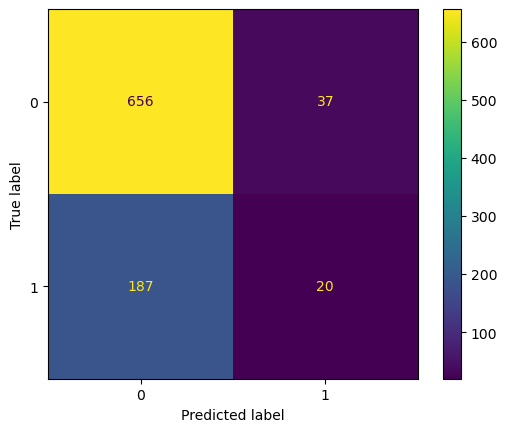

              precision    recall  f1-score   support

         Yes       0.78      0.95      0.85       693
          No       0.35      0.10      0.15       207

    accuracy                           0.75       900
   macro avg       0.56      0.52      0.50       900
weighted avg       0.68      0.75      0.69       900

Logistic Regression Performance: {'accuracy': 0.7511111111111111, 'roc_auc': 0.6997371924908156}


In [66]:
# Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=1000)
logistic_regression_model.fit(X_train, y_train)

print("Logistic Regression Performance:", evaluate_model(logistic_regression_model, X_test, y_test))

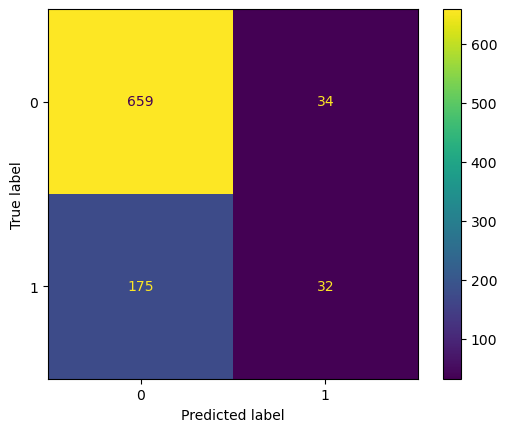

              precision    recall  f1-score   support

         Yes       0.79      0.95      0.86       693
          No       0.48      0.15      0.23       207

    accuracy                           0.77       900
   macro avg       0.64      0.55      0.55       900
weighted avg       0.72      0.77      0.72       900

Random Forest Performance: {'accuracy': 0.7677777777777778, 'roc_auc': 0.6927069173445985}


In [67]:
# Random Forest
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

print("Random Forest Performance:", evaluate_model(random_forest_model, X_test, y_test))

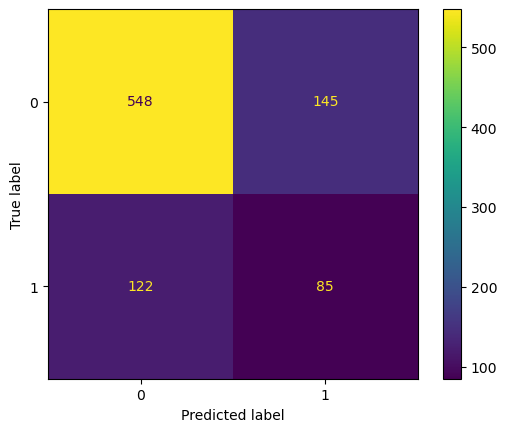

              precision    recall  f1-score   support

         Yes       0.82      0.79      0.80       693
          No       0.37      0.41      0.39       207

    accuracy                           0.70       900
   macro avg       0.59      0.60      0.60       900
weighted avg       0.71      0.70      0.71       900

Neural Network Performance: {'accuracy': 0.7033333333333334, 'roc_auc': 0.6485768659681703}


In [68]:
# Neural Network
neural_network_model = MLPClassifier(hidden_layer_sizes=(50, 25), max_iter=500, random_state=42)
neural_network_model.fit(X_train, y_train)

print("Neural Network Performance:", evaluate_model(neural_network_model, X_test, y_test))

In [69]:
# Quantify and compare how each model’s predictions differ across demographic groups (Gender, Race, Age) to:

# Identify which model is most fair,

# Understand where unfair influence comes from,

# And evaluate the fairness–accuracy trade-off.

In [70]:
def group_binary_metrics(y_true, y_pred, y_prob, group):
    """
    Computes key binary classification metrics for each demographic group.

    Parameters:
    -----------
    y_true : array-like
        Ground truth labels (0/1)
    y_pred : array-like
        Model's binary predictions
    y_prob : array-like
        Model's predicted probabilities
    group : array-like
        Sensitive attribute values (e.g., Gender, Race, Age)

    Returns:
    --------
    DataFrame summarizing metrics per group and overall
    """
    data = pd.DataFrame({
        'y_true': y_true.astype(int),
        'y_pred': y_pred.astype(int),
        'y_prob': y_prob.astype(float),
        'group': group.astype(str)
    })

    rows = []
    for g, df_g in data.groupby('group'):
        n = len(df_g)
        pos = df_g['y_true'].sum()
        neg = n - pos

        # confusion matrix
        tn, fp, fn, tp = confusion_matrix(df_g['y_true'], df_g['y_pred'], labels=[0, 1]).ravel()

        # compute rates
        sr = df_g['y_pred'].mean()  # selection rate
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppv = precision_score(df_g['y_true'], df_g['y_pred'], zero_division=0)
        rec = recall_score(df_g['y_true'], df_g['y_pred'], zero_division=0)
        f1 = f1_score(df_g['y_true'], df_g['y_pred'], zero_division=0)

        auc = roc_auc_score(df_g['y_true'], df_g['y_prob']) if df_g['y_true'].nunique() == 2 else np.nan
        brier = brier_score_loss(df_g['y_true'], df_g['y_prob'])

        rows.append({
            'group': g, 'n': n, 'pos': int(pos), 'neg': int(neg),
            'SR': sr, 'TPR': tpr, 'FPR': fpr, 'PPV': ppv, 'Recall': rec, 'F1': f1,
            'ROC_AUC': auc, 'Brier': brier
        })

    dfm = pd.DataFrame(rows).sort_values('group').reset_index(drop=True)
    return dfm

In [71]:
def fairness_gaps(dfm, ref_group=None):
    """
    Computes fairness gaps vs. a reference group.

    Parameters:
    -----------
    dfm : DataFrame
        Output of group_binary_metrics()
    ref_group : str, optional
        The reference group to compare others against.
        If None, the group with highest Selection Rate (SR) is used.

    Returns:
    --------
    DataFrame with fairness metrics and flags.
    """
    base = dfm.copy()

    # Select reference (group with highest SR by default)
    if ref_group is None:
        ref_group = base.loc[base['SR'].idxmax(), 'group']

    ref = base[base['group'] == ref_group].iloc[0]

    # Compute fairness deltas and ratios
    base['SPD'] = base['SR'] - ref['SR']               # Statistical Parity Difference
    base['DI'] = base['SR'] / ref['SR'] if ref['SR'] > 0 else np.nan  # Disparate Impact
    base['EOD'] = base['TPR'] - ref['TPR']             # Equal Opportunity Difference
    base['EO_FPR'] = base['FPR'] - ref['FPR']          # Equalized Odds (FPR)
    base['ΔPPV'] = base['PPV'] - ref['PPV']            # Predictive Parity Difference
    base['Ref_Group'] = ref_group

    # Flag fairness violations
    def flag(row):
        issues = []
        if row['DI'] < 0.8: issues.append('Adverse Impact (DI<0.8)')
        if abs(row['EOD']) > 0.10: issues.append('TPR gap > 0.10')
        if abs(row['EO_FPR']) > 0.10: issues.append('FPR gap > 0.10')
        if abs(row['ΔPPV']) > 0.10: issues.append('PPV gap > 0.10')
        return ', '.join(issues) if issues else 'OK'

    base['Fairness_Flag'] = base.apply(flag, axis=1)
    return base


In [72]:
def flip_binary_column(X, col):
    # Assumes a one-hot or binary col; for one-hot, swap *_Male and *_Female, etc.
    x = X.copy()
    if col in x.columns and set(x[col].unique())<=set([0,1]):
        x[col] = 1 - x[col]
    return x

def counterfactual_audit(model, X, feature_to_flip):
    Xf = flip_binary_column(X, feature_to_flip)
    p0 = model.predict_proba(X)[:,1]
    p1 = model.predict_proba(Xf)[:,1]
    diffs = np.abs(p0 - p1)
    return {
        'feature': feature_to_flip,
        'avg_change': float(np.mean(diffs)),
        'max_change': float(np.max(diffs)),
        'pct_changed_ge_0_05': float((diffs>=0.05).mean()*100)
    }

In [73]:
# Ground truth
df_test = df_encoded.copy()
# align ground truth & group columns to the test split
df_test = df_encoded.loc[X_test.index].copy()   # rows corresponding to X_test
y_true = y_test.astype(int)

# Model predictions
y_prob_lr  = logistic_regression_model.predict_proba(X_test)[:,1]
y_prob_rf  = random_forest_model.predict_proba(X_test)[:,1]

# For the neural network, prefer predict_proba; handle shapes safely
if hasattr(neural_network_model, "predict_proba"):
    probs_nn = neural_network_model.predict_proba(X_test)
    if probs_nn.ndim == 1:
        y_prob_nn = probs_nn
    else:
        # binary case: take probability of class 1
        y_prob_nn = probs_nn[:, 1] if probs_nn.shape[1] > 1 else probs_nn[:, 0]
else:
    # fallback: use predict (labels) as 0/1 probabilities
    y_prob_nn = neural_network_model.predict(X_test).astype(float)


# Threshold at 0.5 (can tune later)
y_pred_lr = (y_prob_lr >= 0.5).astype(int)
y_pred_rf = (y_prob_rf >= 0.5).astype(int)
y_pred_nn = (y_prob_nn >= 0.5).astype(int)


In [74]:
sensitive_attributes = ['Gender', 'Race', 'Age_Group']

def model_bias_report(name, y_true, y_pred, y_prob, group_col):
    m = group_binary_metrics(y_true, y_pred, y_prob, group_col)
    print(f"Bias Report for {name} by {group_col.name}")
    g = fairness_gaps(m)
    g['Model'] = name
    return g

In [75]:
all_reports = []

for attr in sensitive_attributes:
    all_reports.append(model_bias_report('LogisticRegression', y_true, y_pred_lr, y_prob_lr, df_test[attr]))
    all_reports.append(model_bias_report('RandomForest', y_true, y_pred_rf, y_prob_rf, df_test[attr]))
    all_reports.append(model_bias_report('NeuralNetwork', y_true, y_pred_nn, y_prob_nn, df_test[attr]))

df_fairness = pd.concat(all_reports, ignore_index=True)


summary = df_fairness.groupby(['Model', 'group']).agg({
    'SR': 'mean', 'DI': 'mean', 'EOD': 'mean', 'EO_FPR': 'mean', 'ROC_AUC': 'mean'
}).reset_index()

summary.sort_values(['Model','group'], inplace=True)
summary



Bias Report for LogisticRegression by Gender
Bias Report for RandomForest by Gender
Bias Report for NeuralNetwork by Gender
Bias Report for LogisticRegression by Race
Bias Report for RandomForest by Race
Bias Report for NeuralNetwork by Race
Bias Report for LogisticRegression by Age_Group
Bias Report for RandomForest by Age_Group
Bias Report for NeuralNetwork by Age_Group


,Model,group,SR,DI,EOD,EO_FPR,ROC_AUC
0,LogisticRegression,0,0.068346,0.582801,-0.172721,0.004307,0.674900
1,LogisticRegression,1,0.061505,0.514869,-0.187689,0.000759,0.662137
2,LogisticRegression,2,0.048049,0.396181,-0.175405,-0.020153,0.709773
3,LogisticRegression,3,0.112097,0.630333,-0.037514,-0.030060,0.709273
4,LogisticRegression,4,0.023256,0.250563,-0.127660,-0.050595,0.785714
5,NeuralNetwork,0,0.251968,0.710969,-0.139595,-0.075822,0.616680
6,NeuralNetwork,1,0.278292,0.791155,-0.053417,-0.073672,0.623009
7,NeuralNetwork,2,0.211087,0.605692,-0.143359,-0.121474,0.647784
8,NeuralNetwork,3,0.296774,0.807834,-0.018197,-0.052976,0.701754
9,NeuralNetwork,4,0.186047,0.591805,-0.082447,-0.115476,0.671429


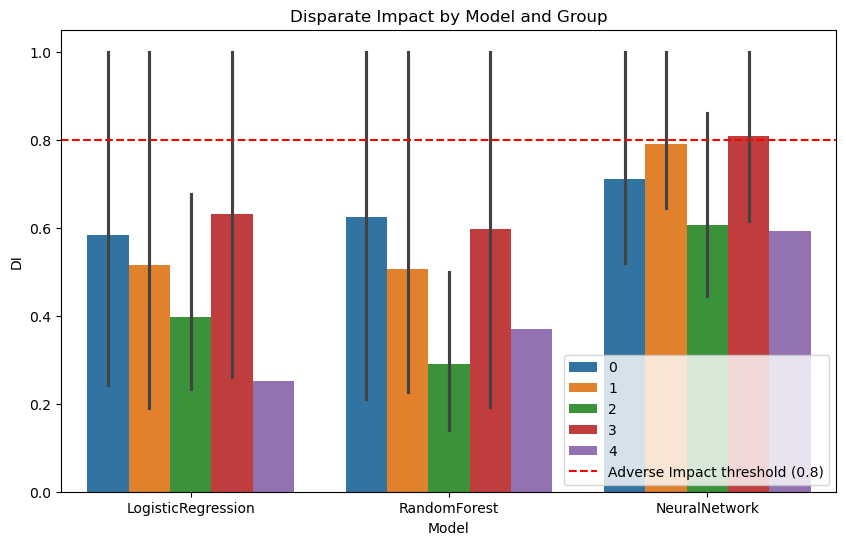

In [76]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_fairness, x='Model', y='DI', hue='group')
plt.axhline(0.8, color='red', linestyle='--', label='Adverse Impact threshold (0.8)')
plt.title('Disparate Impact by Model and Group')
plt.legend()
plt.show()


In [86]:
cf_lr = counterfactual_audit(logistic_regression_model, X_test, 'Gender_Male')
cf_rf = counterfactual_audit(random_forest_model, X_test, 'Gender_Male')
cf_nn = counterfactual_audit(neural_network_model, X_test, 'Gender_Male')

cf_summary = pd.DataFrame([cf_lr, cf_rf, cf_nn])
cf_summary


,feature,avg_change,max_change,pct_changed_ge_0_05
0,Gender_Male,0.0,0.0,0.0
1,Gender_Male,0.0,0.0,0.0
2,Gender_Male,0.0,0.0,0.0
